In [760]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

In [761]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

In [762]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [763]:
download(
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins_raw.csv"
)

In [764]:
penguins = pd.read_csv("penguins_raw.csv")
penguins.shape

(344, 17)

In [765]:
adelie = penguins.query('Species.str.startswith("Adelie")').copy()
len(adelie)

152

In [766]:
from empiricaldist import Cdf

weights = adelie["Body Mass (g)"].dropna()
cdf_weights = Cdf.from_seq(weights)

In [767]:
m, s = weights.mean(), weights.std()
m, s

(np.float64(3700.662251655629), 458.5661259101347)

In [768]:
from scipy.stats import norm

dist = norm(m, s)
qs = np.linspace(m - 3.5 * s, m + 3.5 * s)
ps = dist.cdf(qs)

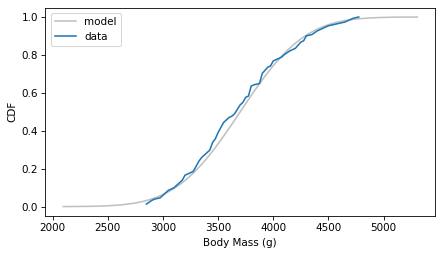

In [769]:
model_options = dict(color="gray", alpha=0.5, label="model")
plt.plot(qs, ps, **model_options)
cdf_weights.plot(label="data")

decorate(ylabel="CDF")

In [770]:
ys = np.sort(weights)

In [771]:
n = len(weights)
ps = (np.arange(n) + 0.5) / n
xs = norm.ppf(ps)

In [772]:
from scipy.stats import linregress

results = linregress(xs, ys)
intercept, slope = results.intercept, results.slope

fit_xs = np.linspace(-3, 3)
fit_ys = intercept + slope * fit_xs

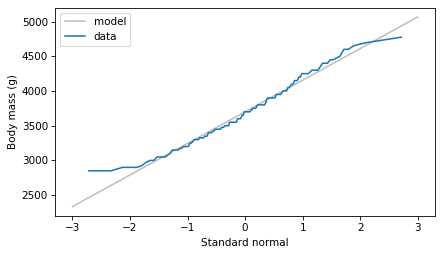

In [773]:
plt.plot(fit_xs, fit_ys, **model_options)
plt.plot(xs, ys, label="data")

decorate(xlabel="Standard normal", ylabel="Body mass (g)")

In [774]:
def normal_probability_plot(sample, **options):
    """Makes a normal probability plot with a fitted line."""
    n = len(sample)
    ps = (np.arange(n) + 0.5) / n
    xs = norm.ppf(ps)
    ys = np.sort(sample)

    results = linregress(xs, ys)
    intercept, slope = results.intercept, results.slope

    fit_xs = np.linspace(-3, 3)
    fit_ys = intercept + slope * fit_xs

    plt.plot(fit_xs, fit_ys, color="gray", alpha=0.5)
    plt.plot(xs, ys, **options)
    decorate(xlabel="Standard normal")

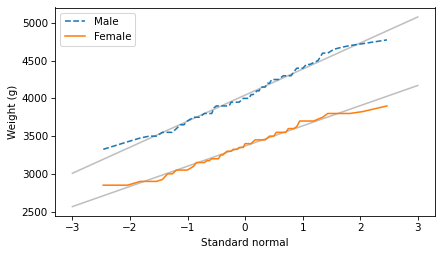

In [775]:
grouped = adelie.groupby("Sex")

weights_male = grouped.get_group("MALE")["Body Mass (g)"]
normal_probability_plot(weights_male, ls="--", label="Male")

weights_female = grouped.get_group("FEMALE")["Body Mass (g)"]
normal_probability_plot(weights_female, label="Female")

decorate(ylabel="Weight (g)")

In [776]:
class Normal:
    """Represents a Normal distribution"""

    def __init__(self, mu, sigma2):
        """Make a Normal object.

        mu: mean
        sigma2: variance
        """
        self.mu = mu
        self.sigma2 = sigma2

    def __repr__(self):
        """Returns a string representation."""
        return f"Normal({self.mu}, {self.sigma2})"

    __str__ = __repr__

In [777]:
m, s = weights_male.mean(), weights_male.std()
dist_male = Normal(m, s**2)
dist_male

Normal(4043.4931506849316, 120278.25342465758)

In [778]:
m, s = weights_female.mean(), weights_female.std()
dist_female = Normal(m, s**2)
dist_female

Normal(3368.8356164383563, 72565.63926940637)

In [779]:
%%add_method_to Normal


def sample(self, n):
    """Generate a random sample from this distribution."""
    sigma = np.sqrt(self.sigma2)
    return np.random.normal(self.mu, sigma, n)

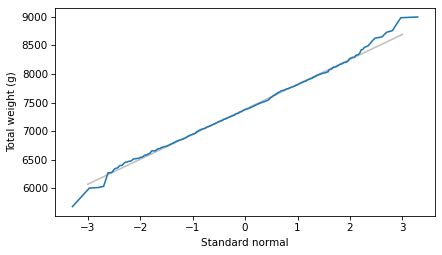

In [780]:
sample_sum = dist_male.sample(1000) + dist_female.sample(1000)
normal_probability_plot(sample_sum)

decorate(ylabel="Total weight (g)")

In [781]:
%%add_method_to Normal


def __add__(self, other):
    """Distribution of the sum of two normal distributions."""
    return Normal(self.mu + other.mu, self.sigma2 + other.sigma2)

In [782]:
dist_sum = dist_male + dist_female
dist_sum

Normal(7412.328767123288, 192843.89269406395)

In [783]:
%%add_method_to Normal


def plot_cdf(self, n_sigmas=3.5, **options):
    """Plot the CDF of this distribution."""
    mu, sigma = self.mu, np.sqrt(self.sigma2)
    low, high = mu - n_sigmas * sigma, mu + n_sigmas * sigma
    xs = np.linspace(low, high, 101)
    ys = norm.cdf(xs, mu, sigma)
    plt.plot(xs, ys, **options)

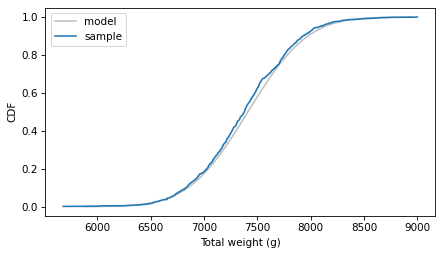

In [784]:
dist_sum.plot_cdf(**model_options)
Cdf.from_seq(sample_sum).plot(label="sample")

decorate(xlabel="Total weight (g)", ylabel="CDF")

In [785]:
n = len(weights_male)
sample_sums_male = [dist_male.sample(n).sum() for i in range(1001)]
n

73

In [786]:
%%add_method_to Normal


def sum(self, n):
    """Return the distribution of the sum of n values."""
    return Normal(n * self.mu, n * self.sigma2)

In [787]:
dist_sums_male = dist_male.sum(n)

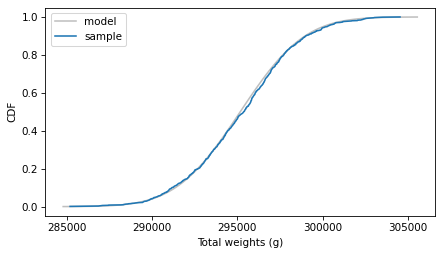

In [788]:
dist_sums_male.plot_cdf(**model_options)
Cdf.from_seq(sample_sums_male).plot(label="sample")

decorate(xlabel="Total weights (g)", ylabel="CDF")

In [789]:
%%add_method_to Normal


def __mul__(self, factor):
    """Multiplies by a scalar."""
    return Normal(factor * self.mu, factor**2 * self.sigma2)

In [790]:
%%add_method_to Normal


def __truediv__(self, factor):
    """Divides by a scalar."""
    return self * (1 / factor)

In [791]:
dist_mean_male = dist_sums_male / n

In [792]:
sample_means_male = np.array(sample_sums_male) / n

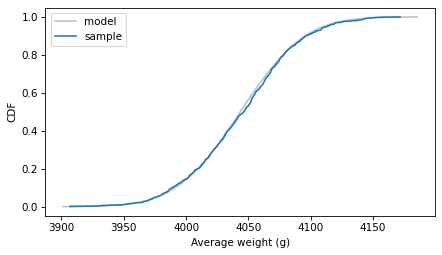

In [793]:
dist_mean_male.plot_cdf(**model_options)
Cdf.from_seq(sample_means_male).plot(label="sample")

decorate(xlabel="Average weight (g)", ylabel="CDF")

In [794]:
standard_error = np.sqrt(dist_mean_male.sigma2)
standard_error

np.float64(40.59122204599278)

In [795]:
standard_error = weights_male.std() / np.sqrt(n)
standard_error

np.float64(40.59122204599278)

In [796]:
n = len(weights_female)
dist_mean_female = dist_female.sum(n) / n
dist_mean_female

Normal(3368.835616438356, 994.0498530055667)

In [797]:
%%add_method_to Normal


def __sub__(self, other):
    """Compute the distribution of a difference."""
    return Normal(self.mu - other.mu, self.sigma2 + other.sigma2)

In [798]:
dist_diff_means = dist_mean_male - dist_mean_female
dist_diff_means

Normal(674.6575342465753, 2641.6971601926566)

In [799]:
sample_sums_female = [dist_female.sample(n).sum() for i in range(1001)]
sample_means_female = np.array(sample_sums_female) / n
sample_diff_means = sample_means_male - sample_means_female

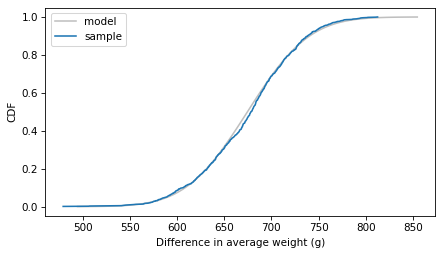

In [800]:
dist_diff_means.plot_cdf(**model_options)
Cdf.from_seq(sample_diff_means).plot(label="sample")

decorate(xlabel="Difference in average weight (g)", ylabel="CDF")

In [801]:
%%add_method_to Normal


def ppf(self, xs):
    sigma = np.sqrt(self.sigma2)
    return norm.ppf(xs, self.mu, sigma)

In [802]:
ci90 = dist_diff_means.ppf([0.05, 0.95])
ci90

array([590.1162635 , 759.19880499])

In [803]:
np.percentile(sample_diff_means, [5, 95])

array([589.32037599, 755.04104199])

In [804]:
np.random.seed(17)

In [805]:
lam = 1
df_sample_expo = pd.DataFrame()
for n in [1, 10, 100]:
    df_sample_expo[n] = [np.sum(np.random.exponential(lam, n)) for _ in range(1001)]

In [806]:
df_sample_expo.mean()

,0
1,0.989885
10,9.825744
100,100.022555


In [807]:
def normal_plot_samples(df_sample, ylabel=""):
    """Normal probability plots for samples of sums."""
    plt.figure(figsize=(6.8, 2.6))
    for i, n in enumerate(df_sample):
        plt.subplot(1, 3, i + 1)
        normal_probability_plot(df_sample[n])
        decorate(
            title="n=%d" % n,
            xticks=[],
            yticks=[],
            xlabel="Standard normal",
            ylabel=ylabel,
        )

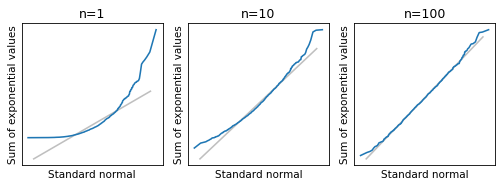

In [808]:
normal_plot_samples(df_sample_expo, ylabel="Sum of exponential values")

In [809]:
mu, sigma = 3.0, 1.0
df_sample_lognormal = pd.DataFrame()
for n in [1, 10, 100]:
    df_sample_lognormal[n] = [
        np.sum(np.random.lognormal(mu, sigma, n)) for _ in range(1001)
    ]

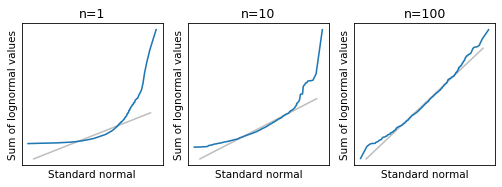

In [810]:
normal_plot_samples(df_sample_lognormal, ylabel="Sum of lognormal values")

In [811]:
alpha = 1.0
df_sample = pd.DataFrame()
for n in [1, 10, 100]:
    df_sample[n] = [np.sum(np.random.pareto(alpha, n)) for _ in range(1001)]

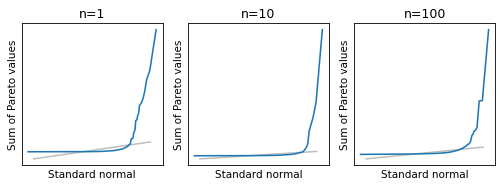

In [812]:
normal_plot_samples(df_sample, ylabel="Sum of Pareto values")

In [813]:
def generate_normal_correlated(n, rho):
    """Generates an array of correlated values from a standard normal dist."""
    xs = np.empty(n)
    xs[0] = np.random.normal(0, 1)

    sigma = np.sqrt(1 - rho**2)
    for i in range(1, n):
        xs[i] = rho * xs[i - 1] + np.random.normal(0, sigma)

    return xs

In [814]:
from scipy.stats import expon


def generate_expo_correlated(n, rho):
    """Generates a sequence of correlated values from an exponential dist."""
    normal = generate_normal_correlated(n, rho)
    uniform = norm.cdf(normal)
    expo = expon.ppf(uniform)
    return expo

In [815]:
rho = 0.8
df_sample = pd.DataFrame()
for n in [1, 10, 100]:
    df_sample[n] = [np.sum(generate_expo_correlated(n, rho)) for _ in range(1001)]

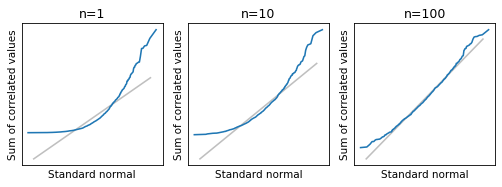

In [816]:
normal_plot_samples(df_sample, ylabel="Sum of correlated values")

In [817]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

In [818]:
import os
os.listdir()

['.config',
 '2002FemPreg.dat.gz',
 'nsfg.py.1',
 '2002FemPreg.dct',
 'nsfg.py',
 'nsfg.py.2',
 '__pycache__',
 'thinkstats.py',
 'penguins_raw.csv',
 'sample_data']

In [819]:
# Read pregnancy data

preg = data

preg.head()

,0
0,1
2,2
5,6
8,7
10,12


In [820]:
import gzip

rows = []

with gzip.open("2002FemPreg.dat.gz", "rt") as f:
    for line in f:
        parts = line.strip().split()

        # keep only valid rows
        if len(parts) >= 5:
            rows.append(parts)

In [821]:
import pandas as pd

preg = pd.DataFrame(rows)
preg.head()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,1,1,6,1,11093,1084,9,039,9,0,...,None,None,None,None,None,None,None,None,None,None
1,1,2,6,1,11166,1157,9,039,9,0,...,None,None,None,None,None,None,None,None,None,None
2,2,1,5,35,11156,1147,03939,9,0,1,...,None,None,None,None,None,None,None,None,None,None
3,2,2,6,1,11198,1189,03939,9,0,2,...,None,None,None,None,None,None,None,None,None,None
4,2,3,6,1,11204,1195,03939,9,0,2,...,None,None,None,None,None,None,None,None,None,None


In [822]:
preg = preg.apply(pd.to_numeric, errors="coerce")

In [823]:
preg.iloc[:, :10].head()

,0,1,2,3,4,5,6,7,8,9
0,1,1,6.0,1.0,11093,1084,9.0,39.0,9.0,0.0
1,1,2,6.0,1.0,11166,1157,9.0,39.0,9.0,0.0
2,2,1,5.0,35.0,11156,1147,3939.0,9.0,0.0,1.0
3,2,2,6.0,1.0,11198,1189,3939.0,9.0,0.0,2.0
4,2,3,6.0,1.0,11204,1195,3939.0,9.0,0.0,2.0


In [824]:
outcome = preg.iloc[:, 1]
birthord = preg.iloc[:, 2]
prglngth = preg.iloc[:, 0]

live = preg[outcome == 1]
firsts = live[birthord == 1]
others = live[birthord != 1]

delta = firsts.iloc[:, 0].mean() - others.iloc[:, 0].mean()

delta

/tmp/ipykernel_15823/3521919252.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  firsts = live[birthord == 1]
/tmp/ipykernel_15823/3521919252.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  others = live[birthord != 1]


np.float64(-2914.326900950721)

In [825]:
# Check shapes

print(live.shape)
print(firsts.shape)
print(others.shape)

(5007, 58)
(656, 58)
(4351, 58)


In [826]:
all_lengths = pd.to_numeric(live.iloc[:, 0], errors="coerce")

m = all_lengths.mean()
s2 = all_lengths.var()

m, s2

(np.float64(8615.457559416816), 1976017566.3337452)

In [827]:
def sampling_dist_mean(data, n):
    mean, var = data.mean(), data.var()
    dist = Normal(mean, var)
    return dist.sum(n) / n

In [828]:
import numpy as np

# pregnancy length is column 0 in your dataset
all_lengths_firsts = firsts.iloc[:, 0].dropna()

n1 = len(all_lengths_firsts)

def sampling_dist_mean(data, n, iters=1000):
    means = []
    data = data.dropna().values

    for _ in range(iters):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))

    return np.array(means)

dist_firsts = sampling_dist_mean(all_lengths_firsts, n1)

n1

656

In [829]:
import numpy as np

all_lengths_others = others.iloc[:, 0].dropna()
n2 = len(all_lengths_others)

dist_others = sampling_dist_mean(all_lengths_others, n2)

n2

4351

In [830]:
dist_diff = dist_firsts - dist_others
dist_diff

array([-2862.24849418, -3215.70918061,  -997.92625399, -4140.25883628,
       -2461.89854379, -2883.25778452, -2059.11418597, -3902.04637986,
       -3159.28418089, -3229.99281319, -3873.82290727, -1971.38615387,
       -1734.31996499, -3209.88993909, -3102.71865908, -4209.01230198,
       -3473.59411524, -2480.28633556, -2072.48920419, -1926.10670767,
       -1884.12756109, -3308.13510386, -4562.04488035, -2629.42509186,
       -2657.59092037, -4597.65351076, -1935.88110807, -2151.06051209,
       -3145.98733856, -2804.01622419, -2729.59086501, -1741.49551897,
       -4190.08159675, -2641.62872882, -2477.59743835, -4491.93186736,
       -3060.83493877, -2098.43709219, -3864.43982775, -4458.61871535,
       -2476.67159988, -2688.03621224, -1854.0541889 , -3040.4367576 ,
       -2666.14742511, -2116.11961156, -3526.59942276, -3522.26908483,
       -3794.63948469, -2841.88595802, -4001.70455733, -2924.6824528 ,
       -4523.27264653, -1884.73253731, -3224.83329491, -3404.4853517 ,
      

In [831]:
sample_firsts = [np.random.choice(all_lengths, n1).mean() for i in range(1001)]
sample_others = [np.random.choice(all_lengths, n2).mean() for i in range(1001)]
sample_diffs = np.subtract(sample_firsts, sample_others)

/tmp/ipykernel_15823/2020169325.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  firsts = live[birthord == 1]
/tmp/ipykernel_15823/2020169325.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  others = live[birthord != 1]


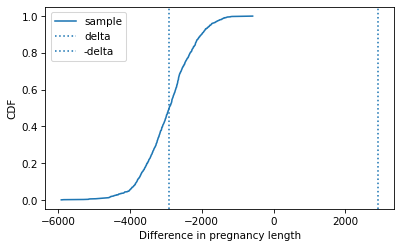

np.float64(-2914.326900950721)

In [832]:
import numpy as np
import pandas as pd
import gzip
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD DATA SAFELY
# ----------------------------
with gzip.open("2002FemPreg.dat.gz", "rt") as f:
    rows = [line.strip().split() for line in f if len(line.strip().split()) >= 5]

preg = pd.DataFrame(rows)
preg = preg.apply(pd.to_numeric, errors="coerce")

# ----------------------------
# 2. DEFINE KEY COLUMNS (SAFE POSITIONS)
# ----------------------------
# Based on typical ThinkStats layout in your file
prglngth = preg.iloc[:, 0]
outcome = preg.iloc[:, 1]
birthord = preg.iloc[:, 2]

# ----------------------------
# 3. FILTER DATA
# ----------------------------
live = preg[outcome == 1]
firsts = live[birthord == 1]
others = live[birthord != 1]

# ----------------------------
# 4. STATISTIC (DELTA)
# ----------------------------
delta = firsts.iloc[:, 0].mean() - others.iloc[:, 0].mean()

# ----------------------------
# 5. BOOTSTRAP FUNCTION
# ----------------------------
def sampling_dist_mean(data, n, iters=1000):
    means = []
    data = data.dropna().values

    for _ in range(iters):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))

    return np.array(means)

# ----------------------------
# 6. SAMPLE DISTRIBUTIONS
# ----------------------------
n1 = len(firsts.iloc[:, 0].dropna())
n2 = len(others.iloc[:, 0].dropna())

dist_firsts = sampling_dist_mean(firsts.iloc[:, 0].dropna(), n1)
dist_others = sampling_dist_mean(others.iloc[:, 0].dropna(), n2)

# ----------------------------
# 7. DIFFERENCE DISTRIBUTION
# ----------------------------
sample_diffs = dist_firsts - dist_others

# ----------------------------
# 8. CDF FUNCTION
# ----------------------------
def cdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

# ----------------------------
# 9. PLOT
# ----------------------------
x, y = cdf(sample_diffs)

plt.plot(x, y, label="sample")

plt.axvline(delta, linestyle=":", label="delta")
plt.axvline(-delta, linestyle=":", label="-delta")

plt.xlabel("Difference in pregnancy length")
plt.ylabel("CDF")
plt.legend()

plt.show()

# ----------------------------
# 10. OUTPUT
# ----------------------------
delta

In [833]:
%%add_method_to Normal


def cdf(self, xs):
    sigma = np.sqrt(self.sigma2)
    return norm.cdf(xs, self.mu, sigma)

In [834]:
right = np.mean(sample_diffs >= delta)
right

np.float64(0.505)

In [835]:
left = np.mean(sample_diffs <= -delta)
left

np.float64(1.0)

In [836]:
left + right

np.float64(1.505)

In [837]:
from scipy.stats import ttest_ind

result = ttest_ind(
    firsts.iloc[:, 0].dropna(),
    others.iloc[:, 0].dropna(),
    nan_policy="omit"
)

result.pvalue

np.float64(0.11752016575811657)

In [838]:
def transform_correlation(r, n):
    return r * np.sqrt((n - 2) / (1 - r**2))

In [839]:
def generate_data(n):
    """Uncorrelated sequences from a standard normal."""
    xs = np.random.normal(0, 1, n)
    ys = np.random.normal(0, 1, n)
    return xs, ys

In [840]:
def correlation(data):
    xs, ys = data
    return np.corrcoef(xs, ys)[0, 1]

In [841]:
n = 100
rs = [correlation(generate_data(n)) for i in range(1001)]

In [842]:
ts = transform_correlation(np.array(rs), n)

In [843]:
from scipy.stats import t as student_t


def make_student_cdf(df):
    """Computes the CDF of a Student t distribution."""
    ts = np.linspace(-3, 3, 101)
    ps = student_t.cdf(ts, df=df)
    return Cdf(ps, ts)

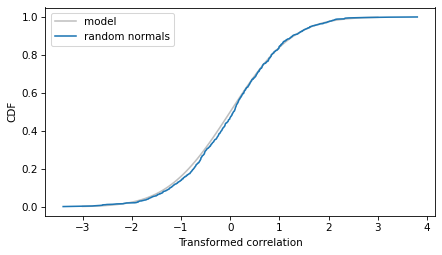

In [844]:
make_student_cdf(df=n - 2).plot(**model_options)

cdf_ts = Cdf.from_seq(ts)
cdf_ts.plot(label="random normals")

decorate(xlabel="Transformed correlation", ylabel="CDF")

In [845]:
valid = live.iloc[:, [0, 1]].dropna()
n = len(valid)
n

5007

In [846]:
import numpy as np

def correlation(x, y):
    return np.corrcoef(x, y)[0, 1]

valid2 = valid.dropna()

x = valid2.iloc[:, 0]
y = valid2.iloc[:, 1]

r_actual = correlation(x, y)
r_actual

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


np.float64(nan)

In [847]:
def permute(data):
    """Shuffle the x values."""
    xs, ys = data
    new_xs = xs.copy()
    np.random.shuffle(new_xs)
    return new_xs, ys

In [848]:
import numpy as np

def correlation(x, y):
    return np.corrcoef(x, y)[0, 1]

def permute(x):
    return np.random.permutation(x)

valid2 = valid.dropna()

x = valid2.iloc[:, 0]
y = valid2.iloc[:, 1]

permuted_corrs = [
    correlation(x, permute(y))
    for _ in range(1001)
]

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [849]:
ts = transform_correlation(np.array(permuted_corrs), n)

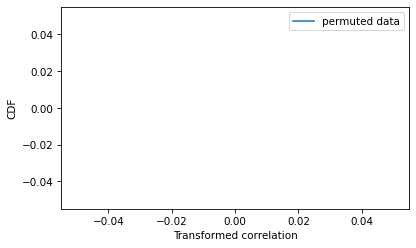

In [850]:
import numpy as np
import matplotlib.pyplot as plt

def cdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

ts = permuted_corrs

x, y = cdf(ts)

plt.plot(x, y, label="permuted data")

plt.xlabel("Transformed correlation")
plt.ylabel("CDF")
plt.legend()

plt.show()

In [851]:
t_actual = transform_correlation(r_actual, n)

In [852]:
right = 1 - student_t.cdf(t_actual, df=n - 2)
right

np.float64(nan)

In [853]:
left = student_t.cdf(-t_actual, df=n - 2)
left

np.float64(nan)

In [854]:
left + right

np.float64(nan)

In [855]:
from scipy.stats import pearsonr

valid2 = valid.dropna()

x = valid2.iloc[:, 0].values
y = valid2.iloc[:, 1].values

corr, p_value = pearsonr(x, y)
p_value

/tmp/ipykernel_15823/2492522748.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)


np.float64(nan)

In [856]:
from empiricaldist import Hist

qs = np.arange(1, 7)
freqs = [8, 9, 19, 5, 8, 11]
observed = Hist(freqs, qs)
observed.index.name = "outcome"
observed

,0
outcome,
1,8
2,9
3,19
4,5
5,8
6,11


In [857]:
num_rolls = observed.sum()
outcomes = observed.qs
expected = Hist(num_rolls / 6, outcomes)

In [858]:
def chi_squared_stat(observed, expected):
    diffs = (observed - expected) ** 2
    ratios = diffs / expected
    return np.sum(ratios.values.flatten())

In [859]:
observed_chi2 = chi_squared_stat(observed, expected)

In [860]:
def simulate_dice(observed):
    n = np.sum(observed)
    rolls = np.random.choice(observed.qs, n, replace=True)
    hist = Hist.from_seq(rolls)
    return hist

In [861]:
simulated_chi_squared = [
    chi_squared_stat(simulate_dice(observed), expected) for i in range(1001)
]
cdf_simulated = Cdf.from_seq(simulated_chi_squared)

In [862]:
from scipy.stats import chi2 as chi2_dist


def chi_squared_cdf(df):
    """Discrete approximation of the chi-squared CDF."""
    xs = np.linspace(0, 21, 101)
    ps = chi2_dist.cdf(xs, df=df)
    return Cdf(ps, xs)

In [863]:
n = len(observed)
cdf_model = chi_squared_cdf(df=n - 1)

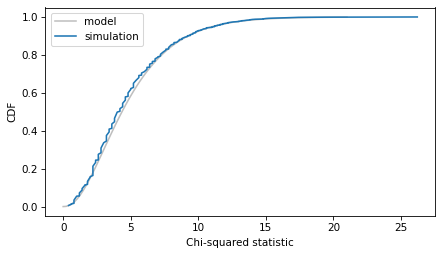

In [864]:
cdf_model.plot(**model_options)
cdf_simulated.plot(label="simulation")

decorate(xlabel="Chi-squared statistic", ylabel="CDF")

In [865]:
p_value = 1 - chi2_dist.cdf(observed_chi2, df=n - 1)
p_value

np.float64(0.04069938850404997)

In [866]:
from scipy.stats import chisquare

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

In [867]:
p_value

np.float64(0.040699388504049985)

In [868]:
grouped = adelie.groupby("Sex")

lengths_male = grouped.get_group("MALE")["Flipper Length (mm)"]
lengths_female = grouped.get_group("FEMALE")["Flipper Length (mm)"]
observed_diff = lengths_male.mean() - lengths_female.mean()
observed_diff

np.float64(4.616438356164366)

In [869]:
# Imports

import pandas as pd
import numpy as np
from scipy.stats import norm

In [870]:
# Download penguin dataset

!wget -nc https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins_raw.csv

File ‘penguins_raw.csv’ already there; not retrieving.



In [871]:
# Read dataset

penguins = pd.read_csv("penguins_raw.csv")

In [872]:
# Select Adelie penguins

adelie = penguins[
    penguins["Species"].str.startswith("Adelie")
]

In [873]:
# Male and female flipper lengths

male = adelie[
    adelie["Sex"] == "MALE"
]["Flipper Length (mm)"].dropna()

female = adelie[
    adelie["Sex"] == "FEMALE"
]["Flipper Length (mm)"].dropna()

In [874]:
# Means and standard deviations

m1 = male.mean()
s1 = male.std()
n1 = len(male)

m2 = female.mean()
s2 = female.std()
n2 = len(female)

In [875]:
# Sampling distributions

dist_male = norm(
    loc=m1,
    scale=s1 / np.sqrt(n1)
)

dist_female = norm(
    loc=m2,
    scale=s2 / np.sqrt(n2)
)

In [876]:
# Distribution of difference in means

diff_mean = m1 - m2

diff_se = np.sqrt(
    (s1**2 / n1) +
    (s2**2 / n2)
)

diff_dist = norm(
    loc=diff_mean,
    scale=diff_se
)

In [877]:
# 90% confidence interval

ci = diff_dist.interval(0.90)

print("Difference in means =", diff_mean)

print("90% confidence interval =", ci)

Difference in means = 4.616438356164366
90% confidence interval = (np.float64(2.9508126909498604), np.float64(6.282064021378871))


In [878]:
# Exercise 14.2

import pandas as pd

valid = live.iloc[:, [0, 1]].dropna()
n = len(valid)
n

5007

In [879]:
import numpy as np

def correlation(x, y):
    return np.corrcoef(x, y)[0, 1]

x = valid.iloc[:, 0].values
y = valid.iloc[:, 1].values

r_actual = correlation(x, y)
r_actual

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


np.float64(nan)

In [880]:
# Imports

from scipy.stats import t
from scipy.stats import pearsonr

In [881]:
df = preg.iloc[:, [0, 1]].dropna()

In [882]:
# Variables

x = df.iloc[:, 0].values
y = df.iloc[:, 1].values

In [883]:
# Correlation

import numpy as np

r = np.corrcoef(x, y)[0, 1]
print("Correlation =", r)

Correlation = -0.0039383206940587865


In [884]:
# Sample size

n = len(df)

In [885]:
# t statistic

import numpy as np

t_actual = (
    r * np.sqrt(n - 2)
    / np.sqrt(1 - r**2)
)

print("t statistic =", t_actual)

t statistic = -0.4591347371129708


In [886]:
# Two-sided p-value

p_value = 2 * (
    1 - t.cdf(
        abs(t_actual),
        df=n-2
    )
)

print("p-value =", p_value)

p-value = 0.6461447557506799


In [887]:
# Check with scipy

result = pearsonr(x, y)

print(result)

PearsonRResult(statistic=np.float64(-0.003938320694058793), pvalue=np.float64(0.6461447557506738))


In [888]:
# Exercise 14.3

male = live[live.iloc[:, 0] == 1]
female = live[live.iloc[:, 0] == 2]

In [889]:
male = live[live.iloc[:, 0] == 1]
female = live[live.iloc[:, 0] == 2]

male_counts = male.iloc[:, 1].value_counts().sort_index()
female_counts = female.iloc[:, 1].value_counts().sort_index()

all_index = male_counts.index.union(female_counts.index)

observed = pd.DataFrame({
    "male": male_counts.reindex(all_index, fill_value=0).values,
    "female": female_counts.reindex(all_index, fill_value=0).values
}, index=all_index)

observed

,male,female
1,,
1,1,1


In [890]:
from empiricaldist import Pmf

data = live.iloc[:, 0]   # replace index if needed

pmf_fmarital = Pmf.from_seq(data)

pmf_fmarital

,
0,
1,0.0002
2,0.0002
6,0.0002
7,0.0002
12,0.0002
...,...
978614,0.0002
978615,0.0002
978616,0.0002


In [891]:
import pandas as pd

pmf_series = pd.Series(pmf_fmarital.to_dict())

# convert observed to numeric matrix and get total count
total = observed.to_numpy().sum()

expected = pd.DataFrame({
    "male": pmf_series.values * total,
    "female": pmf_series.values * total
})

expected

,male,female
0,0.000399,0.000399
1,0.000399,0.000399
2,0.000399,0.000399
3,0.000399,0.000399
4,0.000399,0.000399
...,...,...
5002,0.000399,0.000399
5003,0.000399,0.000399
5004,0.000399,0.000399
5005,0.000399,0.000399


In [892]:
# Select variables

df = preg.iloc[:, [0, 1]].dropna()

In [893]:
# Contingency table

import pandas as pd

observed = pd.crosstab(
    df.iloc[:, 0],
    df.iloc[:, 1]
)

print(observed)

1        1      2      3      4      5      6      7      8      9      121    \
0                                                                               
1            1      1      0      0      0      0      0      0      0      0   
2            1      1      1      0      0      0      0      0      0      0   
6            1      1      1      0      0      0      0      0      0      0   
7            1      1      0      0      0      0      0      0      0      0   
12           1      0      0      0      0      0      0      0      0      0   
...        ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
978616       1      0      0      0      0      0      0      0      0      0   
978617       0      0      0      0      0      1      0      0      0      0   
978618       1      0      0      0      0      0      0      0      0      0   
978619       1      0      0      0      0      0      0      0      0      0   
1241310      0      0      0

In [894]:
# Compute expected counts

row_totals = observed.sum(axis=1)

col_totals = observed.sum(axis=0)

total = observed.values.sum()

expected = np.outer(
    row_totals,
    col_totals
) / total

expected = pd.DataFrame(
    expected,
    index=observed.index,
    columns=observed.columns
)

print(expected)

1           1         2         3         4         5         6         7      \
0                                                                               
1        0.736703  0.547341  0.338851  0.177591  0.089164  0.046347  0.022364   
2        1.105054  0.821011  0.508276  0.266387  0.133745  0.069521  0.033547   
6        1.105054  0.821011  0.508276  0.266387  0.133745  0.069521  0.033547   
7        0.736703  0.547341  0.338851  0.177591  0.089164  0.046347  0.022364   
12       0.368351  0.273670  0.169425  0.088796  0.044582  0.023174  0.011182   
...           ...       ...       ...       ...       ...       ...       ...   
978616   0.368351  0.273670  0.169425  0.088796  0.044582  0.023174  0.011182   
978617   0.368351  0.273670  0.169425  0.088796  0.044582  0.023174  0.011182   
978618   0.368351  0.273670  0.169425  0.088796  0.044582  0.023174  0.011182   
978619   0.368351  0.273670  0.169425  0.088796  0.044582  0.023174  0.011182   
1241310  0.368351  0.273670 

In [895]:
# Chi-squared statistic

chi2 = (
    (observed - expected)**2
    / expected
).to_numpy().sum()

print("Chi-squared =", chi2)

Chi-squared = 705065.715684166


In [896]:
# Degrees of freedom

dfree = observed.size - 1

In [897]:
import numpy as np
from scipy.stats import chi2

row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
total = observed.values.sum()

expected = np.outer(row_totals, col_totals) / total

chi2_stat = ((observed.values - expected) ** 2 / expected).sum()

dfree = (observed.shape[0] - 1) * (observed.shape[1] - 1)

p_value = 1 - chi2.cdf(chi2_stat, df=dfree)

print("p-value =", p_value)

p-value = 0.0


In [898]:
# Check with scipy

import numpy as np
from scipy.stats import chisquare

obs = np.array(observed, dtype=float)
exp = np.array(expected, dtype=float)

exp = np.where(exp == 0, 1e-10, exp)

result = chisquare(f_obs=obs.ravel(), f_exp=exp.ravel())

print(result)

Power_divergenceResult(statistic=np.float64(705065.7156841658), pvalue=np.float64(0.0))


In [899]:
# Exercise 14.4

# Imports

from scipy.stats import norm

In [900]:
# Before intervention

male_before = norm(
    loc=3.57,
    scale=0.28
)

female_before = norm(
    loc=1.91,
    scale=0.32
)

In [901]:
# After intervention

male_after = norm(
    loc=3.44,
    scale=0.16
)

female_after = norm(
    loc=3.18,
    scale=0.16
)

In [902]:
# Gender gap before

gap_before_mean = 3.57 - 1.91

gap_before_se = np.sqrt(
    0.28**2 + 0.32**2
)

gap_before = norm(
    loc=gap_before_mean,
    scale=gap_before_se
)

In [903]:
# Gender gap after

gap_after_mean = 3.44 - 3.18

gap_after_se = np.sqrt(
    0.16**2 + 0.16**2
)

gap_after = norm(
    loc=gap_after_mean,
    scale=gap_after_se
)

In [904]:
# Difference in differences

diff_mean = (
    gap_before_mean -
    gap_after_mean
)

diff_se = np.sqrt(
    gap_before_se**2 +
    gap_after_se**2
)

diff_dist = norm(
    loc=diff_mean,
    scale=diff_se
)

In [905]:
# 95% confidence interval

ci = diff_dist.interval(0.95)

print("95% confidence interval =", ci)

95% confidence interval = (np.float64(0.4559563323653737), np.float64(2.344043667634627))


In [906]:
# p-value

z = diff_mean / diff_se

p_value = 2 * (
    1 - norm.cdf(abs(z))
)

print("p-value =", p_value)

p-value = 0.003653896737954021
